In [ ]:
import os, sys, traceback
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression, LinearRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import lightgbm as lgb
from xgboost import XGBClassifier

# -----------------------
# USER FLAGS (edit if needed)
# -----------------------
DATA_DIR = "data"     # where your Borrower.txt / Loan.txt live
RUN_HEAVY_MODELS = False   # set True to run SVC (probability=True) and KNN on full data (can be slow)
QUICK_RUN = False          # set True to downsample train set for quick debugging
SAVE_BEST_AS = "best_model.joblib"

# -----------------------
# paths
# -----------------------
borrower_path = os.path.join(DATA_DIR, "D:\SpringBoard\CreditPathAI\data\Borrower.txt")
loan_path = os.path.join(DATA_DIR, "D:\SpringBoard\CreditPathAI\data\Loan.txt")
if not os.path.exists(loan_path) and os.path.exists(os.path.join(DATA_DIR, "Loan_default.csv")):
    loan_path = os.path.join(DATA_DIR, "Loan_default.csv")

print("Borrower:", borrower_path, "exists?", os.path.exists(borrower_path))
print("Loan:    ", loan_path,     "exists?", os.path.exists(loan_path))
if not os.path.exists(borrower_path) or not os.path.exists(loan_path):
    raise FileNotFoundError("One or both input files missing. Put Borrower.txt and Loan.txt inside 'data/' or edit DATA_DIR.")

# -----------------------
# robust reader
# -----------------------
def robust_read_table(path):
    try:
        df = pd.read_csv(path, sep="\t", engine="python")
        if df.shape[1] == 1:
            df2 = pd.read_csv(path, sep=",", engine="python")
            if df2.shape[1] > 1:
                return df2
        return df
    except Exception:
        return pd.read_csv(path, sep=",", engine="python")

df_b = robust_read_table(borrower_path)
df_l = robust_read_table(loan_path)

# merge if possible
if "memberId" in df_b.columns and "memberId" in df_l.columns:
    df = pd.merge(df_b, df_l, on="memberId", how="inner")
else:
    df = df_l.copy()

print("Merged df shape:", df.shape)

# drop ids if present
for c in ("memberId","loanId"):
    if c in df.columns:
        df.drop(c, axis=1, inplace=True)

# -----------------------
# basic imputation
# -----------------------
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object","category"]).columns.tolist()

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

if num_cols:
    df[num_cols] = num_imputer.fit_transform(df[num_cols])
if cat_cols:
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# -----------------------
# target and features
# -----------------------
if "loanStatus" not in df.columns:
    raise ValueError("loanStatus not found in the dataset")

y = df["loanStatus"].map({"Current":0,"Default":1})
X = df.drop("loanStatus", axis=1)

# -----------------------
# feature engineering (safe)
# -----------------------
if "date" in X.columns:
    X["date"] = pd.to_datetime(X["date"], errors="coerce")
    X["loan_issue_year"] = X["date"].dt.year.fillna(0).astype(int)
    X["loan_issue_month"] = X["date"].dt.month.fillna(0).astype(int)
    X["loan_issue_dayofweek"] = X["date"].dt.dayofweek.fillna(0).astype(int)
    X.drop("date", axis=1, inplace=True)

if "yearsEmployment" in X.columns:
    emp_map = {"< 1 year":0.5, "1 year":1, "2-5 years":3.5, "6-9 years":7.5, "10+ years":10}
    X["yearsEmployment"] = X["yearsEmployment"].map(emp_map).fillna(0)

if "term" in X.columns:
    X["term"] = X["term"].astype(str).str.replace(" months","", regex=False)
    X["term"] = pd.to_numeric(X["term"], errors="coerce").fillna(0)

if "grade" in X.columns:
    order = ['A1','A2','A3','B1','B2','B3','C1','C2','C3','D1','D2','D3','E1','E2','E3']
    mapper = {k:i for i,k in enumerate(order)}
    X["grade"] = X["grade"].map(mapper).fillna(0)

# -----------------------
# One-hot encode nominal columns (safe)
# -----------------------
nominal_cols = [c for c in X.columns if X[c].dtype == "object"]
if nominal_cols:
    # compatibility: sklearn may have different parameter name for sparse output
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    X_ohe = pd.DataFrame(ohe.fit_transform(X[nominal_cols]),
                         columns=ohe.get_feature_names_out(nominal_cols),
                         index=X.index)
    X = pd.concat([X.drop(columns=nominal_cols), X_ohe], axis=1)

# final NaN fill
X = X.fillna(0)
y = y.fillna(0).astype(int)

# -----------------------
# optional quick-run downsample for debugging
# -----------------------
if QUICK_RUN:
    print("QUICK_RUN: downsampling to 20k rows for fast debugging")
    sample_idx = X.sample(n=min(20000, len(X)), random_state=42).index
    X = X.loc[sample_idx]
    y = y.loc[sample_idx]

# -----------------------
# train-test split & scaling
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Class distribution in train:\n", y_train.value_counts())

# -----------------------
# models to run (skip heavy by default)
# -----------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(class_weight="balanced", random_state=42, verbosity=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=(y_train.value_counts().iloc[0]/y_train.value_counts().iloc[1]),
                             eval_metric="logloss", random_state=42, use_label_encoder=False, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SGD (linear)": SGDClassifier(loss="hinge", max_iter=2000, tol=1e-3, random_state=42),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis()
}

# Add heavier models optionally
if RUN_HEAVY_MODELS:
    models["SVC (RBF)"] = SVC(kernel="rbf", probability=True, random_state=42)
    models["KNN"] = KNeighborsClassifier()

# LinearRegression (thresholded) - included but won't win by ROC usually
from sklearn.linear_model import LinearRegression
models["Linear Regression (thresholded)"] = LinearRegression()

# -----------------------
# training loop with safe error handling
# -----------------------
results = {}
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    try:
        model.fit(X_train, y_train)
    except Exception as e:
        print(f"Model {name} failed during fit: {e}")
        traceback.print_exc(limit=1)
        results[name] = {"error": str(e)}
        continue

    # Predict & probability handling
    try:
        if name.startswith("Linear Regression"):
            y_cont = model.predict(X_test)
            y_pred = (y_cont >= 0.5).astype(int)
            y_proba = np.clip(y_cont, 0, 1)
        else:
            y_pred = model.predict(X_test)
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test)[:,1]
            elif hasattr(model, "decision_function"):
                scores = model.decision_function(X_test)
                y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
            else:
                y_proba = y_pred  # fallback
    except Exception as e:
        print(f"Model {name} failed during predict/proba: {e}")
        traceback.print_exc(limit=1)
        results[name] = {"error": str(e)}
        continue

    # Metrics
    try:
        acc = accuracy_score(y_test, y_pred)
        try:
            roc = roc_auc_score(y_test, y_proba)
        except Exception:
            roc = float("nan")
        rec = None
        try:
            from sklearn.metrics import recall_score
            rec = recall_score(y_test, y_pred)
        except Exception:
            rec = None

        print("Accuracy:", round(acc,4))
        print("ROC-AUC:", round(roc,4) if not np.isnan(roc) else "NA")
        if rec is not None:
            print("Recall:", round(rec,4))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))
        results[name] = {"accuracy": acc, "roc_auc": roc, "recall": rec}
    except Exception as e:
        print(f"Metric calculation failed for {name}: {e}")
        traceback.print_exc(limit=1)
        results[name] = {"error": str(e)}
        continue

# -----------------------
# choose best model by ROC-AUC (exclude Linear Regression)
# -----------------------
valid = {k:v for k,v in results.items() if isinstance(v, dict) and "roc_auc" in v and not np.isnan(v["roc_auc"]) and "Linear Regression" not in k}
if not valid:
    print("No valid models with ROC-AUC found to save.")
else:
    best_name = max(valid.keys(), key=lambda k: valid[k]["roc_auc"])
    print("\nBest model by ROC-AUC:", best_name, "score:", valid[best_name]["roc_auc"])
    best_model = models[best_name]
    joblib.dump(best_model, SAVE_BEST_AS)
    print("Saved best model to:", SAVE_BEST_AS)

# -----------------------
# print summary of runs
# -----------------------
print("\nSummary of runs:")
for k,v in results.items():
    print(k, "->", v)

print("\nDone.")


<>:38: SyntaxWarning: invalid escape sequence '\S'
<>:39: SyntaxWarning: invalid escape sequence '\S'
<>:38: SyntaxWarning: invalid escape sequence '\S'
<>:39: SyntaxWarning: invalid escape sequence '\S'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15232\1784808719.py:38: SyntaxWarning: invalid escape sequence '\S'
  borrower_path = os.path.join(DATA_DIR, "D:\SpringBoard\CreditPathAI\data\Borrower.txt")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15232\1784808719.py:39: SyntaxWarning: invalid escape sequence '\S'
  loan_path = os.path.join(DATA_DIR, "D:\SpringBoard\CreditPathAI\data\Loan.txt")


Borrower: D:\SpringBoard\CreditPathAI\data\Borrower.txt exists? True
Loan:     D:\SpringBoard\CreditPathAI\data\Loan.txt exists? True
Merged df shape: (100000, 27)
Train shape: (80000, 82) Test shape: (20000, 82)
Class distribution in train:
 loanStatus
0    71997
1     8003
Name: count, dtype: int64

=== Training Logistic Regression ===
Accuracy: 0.8389
ROC-AUC: 0.9154
Recall: 0.8336
Confusion Matrix:
 [[15110  2889]
 [  333  1668]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.90     17999
           1       0.37      0.83      0.51      2001

    accuracy                           0.84     20000
   macro avg       0.67      0.84      0.71     20000
weighted avg       0.92      0.84      0.86     20000


=== Training Random Forest ===
Accuracy: 0.9219
ROC-AUC: 0.9085
Recall: 0.2649
Confusion Matrix:
 [[17908    91]
 [ 1471   530]]
Classification Report:
               precision    recall  f1-score   support

  

In [ ]:
# End-to-End Loan Default Prediction Pipeline
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import lightgbm as lgb
from xgboost import XGBClassifier

import joblib

# -----------------------------
# Paths
# -----------------------------
DATA_DIR = "data"   # <-- adjust if needed
borrower_path = os.path.join(DATA_DIR, "D:\SpringBoard\CreditPathAI\data\Borrower.txt")
loan_path = os.path.join(DATA_DIR, "D:\SpringBoard\CreditPathAI\data\Loan.txt")

# fallback: Loan_default.csv
if not os.path.exists(loan_path) and os.path.exists(os.path.join(DATA_DIR, "Loan_default.csv")):
    loan_path = os.path.join(DATA_DIR, "Loan_default.csv")

print("Borrower file:", borrower_path, "Exists:", os.path.exists(borrower_path))
print("Loan file:    ", loan_path, "Exists:", os.path.exists(loan_path))

# -----------------------------
# Robust Loader
# -----------------------------
def robust_read_table(path):
    """Try tab, fallback to comma"""
    try:
        df = pd.read_csv(path, sep="\t", engine="python")
        if df.shape[1] == 1:  # maybe comma-separated
            df2 = pd.read_csv(path, sep=",", engine="python")
            if df2.shape[1] > 1:
                print(f"Detected comma-separated file: {path}")
                return df2
        return df
    except Exception:
        return pd.read_csv(path, sep=",", engine="python")

# -----------------------------
# Load + Merge
# -----------------------------
df_borrower = robust_read_table(borrower_path)
df_loan = robust_read_table(loan_path)

# if both have memberId, merge
if "memberId" in df_borrower.columns and "memberId" in df_loan.columns:
    df = pd.merge(df_borrower, df_loan, on="memberId", how="inner")
else:
    # fallback: assume loan file already contains all
    df = df_loan.copy()

print("Merged shape:", df.shape)
display(df.head())

# -----------------------------
# Drop IDs
# -----------------------------
for col in ["memberId", "loanId"]:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True, errors="ignore")

# -----------------------------
# Handle Missing Values
# -----------------------------
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# -----------------------------
# Encode target
# -----------------------------
if "loanStatus" not in df.columns:
    raise ValueError("loanStatus column not found in dataset!")

target_map = {"Current": 0, "Default": 1}
y = df["loanStatus"].map(target_map)
X = df.drop("loanStatus", axis=1)

# -----------------------------
# Feature Engineering
# -----------------------------
# Date -> Year/Month/Day
if "date" in X.columns:
    X["date"] = pd.to_datetime(X["date"], errors="coerce")
    X["loan_issue_year"] = X["date"].dt.year
    X["loan_issue_month"] = X["date"].dt.month
    X["loan_issue_dayofweek"] = X["date"].dt.dayofweek
    X.drop("date", axis=1, inplace=True)

# Employment
if "yearsEmployment" in X.columns:
    emp_map = {
        "< 1 year": 0.5, "1 year": 1, "2-5 years": 3.5,
        "6-9 years": 7.5, "10+ years": 10
    }
    X["yearsEmployment"] = X["yearsEmployment"].map(emp_map)

# Term (convert "36 months" -> 36)
if "term" in X.columns:
    X["term"] = X["term"].str.replace(" months", "").astype(float)

# Grade mapping
if "grade" in X.columns:
    grade_map = {f"{g}{i}": idx for idx, (g, i) in enumerate(
        [(a, b) for a in "ABCDE" for b in [1, 2, 3]])}
    X["grade"] = X["grade"].map(grade_map)

# -----------------------------
# One-Hot Encoding
# -----------------------------
nominal_cols = [c for c in X.columns if X[c].dtype == "object"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_ohe = pd.DataFrame(
    ohe.fit_transform(X[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X.index
)

X = pd.concat([X.drop(columns=nominal_cols), X_ohe], axis=1)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
X_train[X_train.columns] = scaler.fit_transform(X_train)
X_test[X_test.columns] = scaler.transform(X_test)

# -----------------------------
# Train Models
# -----------------------------
counts = y_train.value_counts()
scale_pos_weight = counts[0] / counts[1]
print("Class balance:", counts.to_dict(), " scale_pos_weight:", scale_pos_weight)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "LightGBM": lgb.LGBMClassifier(class_weight="balanced", random_state=42, verbosity=-1),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, preds)
    print("Accuracy:", acc)
    print("ROC-AUC:", auc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Classification Report:\n", classification_report(y_test, preds))
    results[name] = (acc, auc)

# -----------------------------
# Save Best Model
# -----------------------------
best_model_name = max(results, key=lambda k: results[k][1])
best_model = models[best_model_name]
joblib.dump(best_model, "xgb_pipeline.joblib")

print("\nBest model:", best_model_name, "saved as xgb_pipeline.joblib")


Borrower file: D:\SpringBoard\CreditPathAI\data\Borrower.txt Exists: True
Loan file:     D:\SpringBoard\CreditPathAI\data\Loan.txt Exists: True
Merged shape: (100000, 27)


,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,...,loanId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,...,1888978,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,...,1299695,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,...,1875016,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,...,1440478,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,...,1124634,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current


Class balance: {0: 71997, 1: 8003}  scale_pos_weight: 8.996251405722854

--- Logistic Regression ---
Accuracy: 0.8389
ROC-AUC: 0.8365371456168686
Confusion Matrix:
 [[15110  2889]
 [  333  1668]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.90     17999
           1       0.37      0.83      0.51      2001

    accuracy                           0.84     20000
   macro avg       0.67      0.84      0.71     20000
weighted avg       0.92      0.84      0.86     20000


--- Random Forest ---
Accuracy: 0.9219
ROC-AUC: 0.629905864890767
Confusion Matrix:
 [[17908    91]
 [ 1471   530]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96     17999
           1       0.85      0.26      0.40      2001

    accuracy                           0.92     20000
   macro avg       0.89      0.63      0.68     20000
weighted avg       0.92      0.92      0

Training shape: (80000, 82)  Pos class count: 8003
Starting GridSearchCV (optimizing recall) ... this may take a while.
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best grid-search params: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}

Test Accuracy: 0.8925
Test Recall:   0.6702
ROC-AUC:       0.9053032792454265
PR-AUC:        0.5981

Confusion matrix:
 [[16509  1490]
 [  660  1341]]

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94     17999
           1       0.47      0.67      0.56      2001

    accuracy                           0.89     20000
   macro avg       0.72      0.79      0.75     20000
weighted avg       0.91      0.89      0.90     20000


Saved best pipeline to: best_pipe_smote_xgb.joblib

Computing SHAP values (may take a minute)...
Saved shap_summary_dot.png


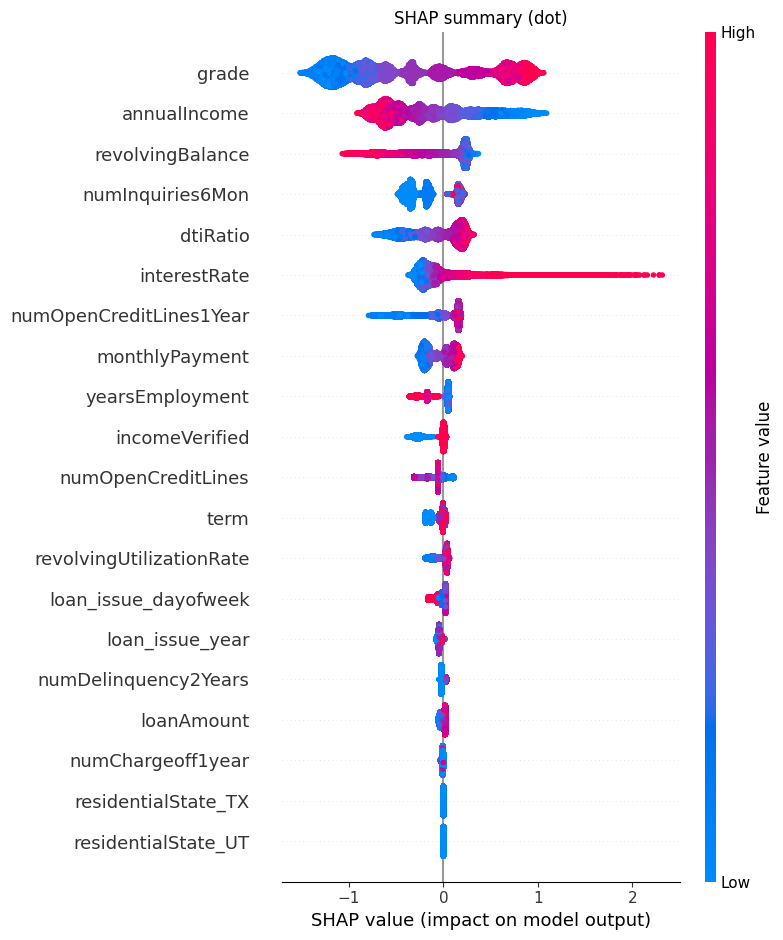

Saved shap_summary_bar.png


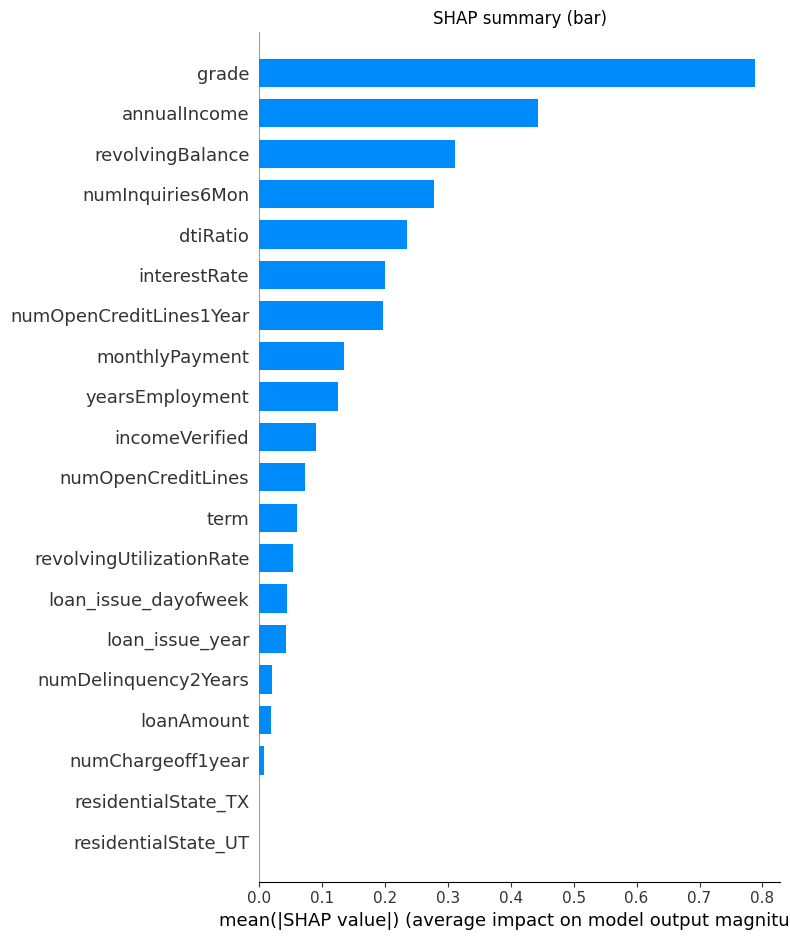


SHAP plots generated and saved.


In [ ]:
# ---------------------------
# SMOTE + GridSearch (recall) + SHAP explanations 
# ---------------------------

import sys, os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, recall_score, precision_recall_curve, auc,
                             roc_auc_score, confusion_matrix, classification_report)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import shap

# Safety checks: X_train/X_test/y_train/y_test must exist
for name in ("X_train","X_test","y_train","y_test"):
    if name not in globals():
        raise RuntimeError(f"{name} is not defined. Run preprocessing cells first to create X_train, X_test, y_train, y_test")

# Convert to numpy arrays to avoid pandas indexing nuances in imblearn pipelines
X_train_arr = X_train.values if hasattr(X_train, "values") else X_train
X_test_arr  = X_test.values if hasattr(X_test, "values") else X_test
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train
y_test_arr  = y_test.values if hasattr(y_test, "values") else y_test

print("Training shape:", X_train_arr.shape, " Pos class count:", np.sum(y_train_arr==1))

# --- Build pipeline: SMOTE -> Scaler -> XGB ---
# NOTE: SMOTE does NOT accept n_jobs; remove that argument.
pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),      # safe even with OHE columns
    ("xgb", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_jobs=-1))
])

# --- Grid for XGBoost focused on recall ---
param_grid = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [3, 6],
    "xgb__learning_rate": [0.05, 0.1],
    # small grid - expand later if you want
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="recall",       # optimize recall for minority class
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print("Starting GridSearchCV (optimizing recall) ... this may take a while.")
gs.fit(X_train_arr, y_train_arr)

print("\nBest grid-search params:", gs.best_params_)
best_pipe = gs.best_estimator_

# --- Evaluate on test set ---
y_pred = best_pipe.predict(X_test_arr)

# For probabilities, call predict_proba on pipeline; it routes to xgb
y_proba = None
try:
    y_proba = best_pipe.predict_proba(X_test_arr)[:,1]
except Exception:
    y_proba = None

if y_proba is None:
    # fallback to decision_function if available
    try:
        y_scores = best_pipe.decision_function(X_test_arr)
        y_proba = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min() + 1e-12)
    except Exception:
        y_proba = y_pred  # last resort (not ideal)

acc = accuracy_score(y_test_arr, y_pred)
rec = recall_score(y_test_arr, y_pred)
# protect roc_auc_score call in case probabilities are degenerate
try:
    roc = roc_auc_score(y_test_arr, y_proba)
except Exception:
    roc = float("nan")
precision, recall_vals, _ = precision_recall_curve(y_test_arr, y_proba)
pr_auc = auc(recall_vals, precision)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"Test Recall:   {rec:.4f}")
print(f"ROC-AUC:       {roc if not np.isnan(roc) else 'NA'}")
print(f"PR-AUC:        {pr_auc:.4f}")
print("\nConfusion matrix:\n", confusion_matrix(y_test_arr, y_pred))
print("\nClassification report:\n", classification_report(y_test_arr, y_pred))

# Save best pipeline
joblib.dump(best_pipe, "best_pipe_smote_xgb.joblib")
print("\nSaved best pipeline to: best_pipe_smote_xgb.joblib")

# -------------------------
# SHAP explainability (TreeExplainer for XGBoost)
# -------------------------
print("\nComputing SHAP values (may take a minute)...")
# Extract trained xgb model inside the pipeline
xgb_model = best_pipe.named_steps['xgb']

# Retrieve scaler from pipeline to transform original X_train for SHAP background
scaler_step = best_pipe.named_steps['scaler']
X_train_scaled_for_shap = scaler_step.transform(X_train_arr)  # shape (n_train, n_features)

# Use a sample (background) to keep SHAP fast/memory-friendly
n_background = min(200, X_train_scaled_for_shap.shape[0])
background = X_train_scaled_for_shap[np.random.choice(X_train_scaled_for_shap.shape[0], n_background, replace=False)]

# TreeExplainer for XGBoost (fast)
try:
    explainer = shap.TreeExplainer(xgb_model)
    # shap_values shape depends on model; for binary classifier we'll get array (n_samples, n_features)
    shap_values = explainer.shap_values(X_train_scaled_for_shap)
except Exception as e:
    print("TreeExplainer failed, falling back to KernelExplainer (slower):", e)
    explainer = shap.KernelExplainer(lambda x: xgb_model.predict_proba(x)[:,1], background)
    shap_values = explainer.shap_values(X_train_scaled_for_shap[:200])  # smaller subset

# Prepare feature names (scaled input uses X_train.columns order)
feature_names = list(X_train.columns)

# SHAP summary plot (dot)
plt.figure(figsize=(10,6))
try:
    shap.summary_plot(shap_values, X_train_scaled_for_shap, feature_names=feature_names, show=False)
    plt.title("SHAP summary (dot)")
    plt.tight_layout()
    plt.savefig("shap_summary_dot.png", dpi=150)
    print("Saved shap_summary_dot.png")
    plt.show()
except Exception as e:
    print("Failed to create SHAP dot plot:", e)

# SHAP bar plot
plt.figure(figsize=(10,6))
try:
    shap.summary_plot(shap_values, X_train_scaled_for_shap, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("SHAP summary (bar)")
    plt.tight_layout()
    plt.savefig("shap_summary_bar.png", dpi=150)
    print("Saved shap_summary_bar.png")
    plt.show()
except Exception as e:
    print("Failed to create SHAP bar plot:", e)

print("\nSHAP plots generated and saved.")
